# Intel Image Classification

This notebook builds a CNN for the [Intel Image Classification dataset](https://www.kaggle.com/datasets/puneet6060/intel-image-classification).

**Dataset:** 6 classes, ~25,000 images  
**Model:** Sequential CNN with Conv2D and MaxPooling2D layers on top of a EfficientNetB0 base  
**Target:** >= 95% accuracy on train and test (minimum required: 85%)


In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
# RTX 5060 (compute capability 12.0) is not supported by TensorFlow 2.19.
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

# Patch protobuf version validator: tensorflowjs 4.22 depends on
# tensorflow-decision-forests compiled with protobuf 6, but TF 2.19 pins
# protobuf 5. Skipping the runtime version check lets TFJS load safely.
import google.protobuf.runtime_version
def _validate_protobuf_version(*args, **kwargs):
    pass
google.protobuf.runtime_version.ValidateProtobufRuntimeVersion = _validate_protobuf_version

import json
import shutil
import pathlib
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers, regularizers
import kagglehub

print("TensorFlow version:", tf.__version__)
print("KaggleHub version:", kagglehub.__version__)
print("GPU available:", tf.config.list_physical_devices("GPU"))
print("Running on CPU with float32 precision.")

# Reproducibility
tf.random.set_seed(42)
np.random.seed(42)


2026-08-27 19:56:33.830241: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1787835393.840895   50063 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1787835393.843991   50063 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1787835393.855761   50063 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1787835393.855794   50063 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1787835393.855795   50063 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
KaggleHub version: 1.0.2
GPU available: []
Running on CPU with float32 precision.


2026-08-27 19:56:38.290871: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


In [2]:
# Hyperparameters and paths
DATASET_NAME = "puneet6060/intel-image-classification"
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS_TOP = 50
LEARNING_RATE_TOP = 1e-3
NUM_CLASSES = 6
SEED = 42


## Download dataset from Kaggle

The notebook uses `kagglehub`. Before running the next cell, set your Kaggle credentials **outside the notebook** using one of these methods:

1. Environment variables:
   ```bash
   export KAGGLE_USERNAME=your_username
   export KAGGLE_KEY=your_key
   ```
2. Or place `kaggle.json` in `~/.kaggle/` with `chmod 600 ~/.kaggle/kaggle.json`.

The credentials are **not** stored in this notebook.


In [3]:
# Verify credentials are available before downloading.
# If the dataset is already cached, credentials are not required.
dataset_path = kagglehub.dataset_download(DATASET_NAME)
if dataset_path is None:
    if not os.environ.get("KAGGLE_USERNAME") and not os.path.exists(os.path.expanduser("~/.kaggle/kaggle.json")):
        raise RuntimeError(
            "Kaggle credentials not found. Set KAGGLE_USERNAME/KAGGLE_KEY env vars "
            "or create ~/.kaggle/kaggle.json."
        )
    dataset_path = kagglehub.dataset_download(DATASET_NAME)
print("Dataset path:", dataset_path)


Dataset path: /home/vincentoei/.cache/kagglehub/datasets/puneet6060/intel-image-classification/versions/2


In [4]:
# Show top-level directory structure
def print_tree(startpath, max_depth=2):
    for root, dirs, files in os.walk(startpath):
        level = root.replace(startpath, "").count(os.sep)
        if level > max_depth:
            continue
        indent = " " * 2 * level
        print(f"{indent}{os.path.basename(root)}/")

print_tree(dataset_path)


2/
  seg_pred/
    seg_pred/
  seg_train/
    seg_train/
  seg_test/
    seg_test/


## Load train / validation / test splits

The original images have non-uniform resolutions. `image_dataset_from_directory` resizes them to `IMG_SIZE` on the fly, so the pipeline handles mixed resolutions without manual preprocessing.


In [5]:
train_dir = os.path.join(dataset_path, "seg_train", "seg_train")
test_dir = os.path.join(dataset_path, "seg_test", "seg_test")

# Training set: 80% of seg_train
# Validation set: 20% of seg_train
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
    validation_split=0.2,
    subset="training",
    label_mode="categorical",
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
    validation_split=0.2,
    subset="validation",
    label_mode="categorical",
)

# Test set: seg_test
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
    label_mode="categorical",
)

class_names = train_ds.class_names
NUM_CLASSES = len(class_names)
print("Classes:", class_names)
print("Num classes:", NUM_CLASSES)


Found 14034 files belonging to 6 classes.


Using 11228 files for training.


Found 14034 files belonging to 6 classes.


Using 2806 files for validation.


Found 3000 files belonging to 6 classes.


Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Num classes: 6


In [6]:
with open("class_names.json", "w") as f:
    json.dump(class_names, f)
print("Saved class_names.json")


Saved class_names.json


In [7]:
AUTOTUNE = tf.data.AUTOTUNE

# Data augmentation applied only during training, via tf.data pipeline.
# The exported model contains no augmentation layers.
augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
], name="data_augmentation")

def augment(image, label):
    return augmentation(image, training=True), label

train_ds = train_ds.map(augment, num_parallel_calls=AUTOTUNE)
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)


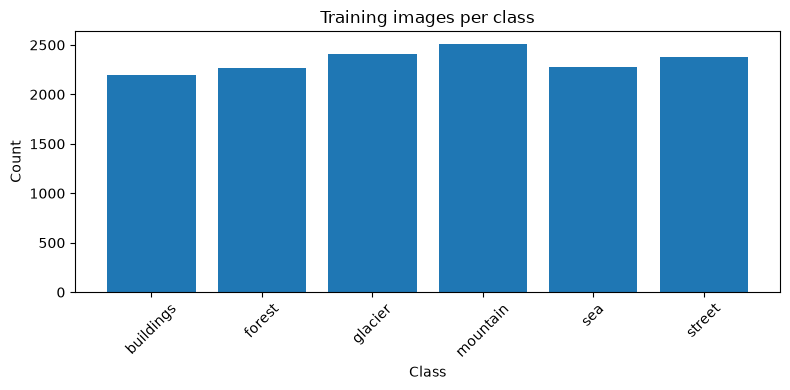

{'buildings': 2191, 'forest': 2271, 'glacier': 2404, 'mountain': 2512, 'sea': 2274, 'street': 2382}


In [8]:
# Count images per class in the raw training directory
class_counts = {}
for cls in sorted(os.listdir(train_dir)):
    cls_path = os.path.join(train_dir, cls)
    if os.path.isdir(cls_path):
        class_counts[cls] = len([f for f in os.listdir(cls_path) if os.path.isfile(os.path.join(cls_path, f))])

plt.figure(figsize=(8, 4))
plt.bar(class_counts.keys(), class_counts.values())
plt.title("Training images per class")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("class_distribution.png")
plt.show()
print(class_counts)


## Build the Sequential CNN model

A lightweight EfficientNetB0 pretrained base (frozen) plus a custom Conv2D/Pooling top. No feature caching, so memory stays within WSL limits.


In [9]:
base_model = tf.keras.applications.EfficientNetB0(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights="imagenet",
)
base_model.trainable = False

model = models.Sequential([
    layers.InputLayer(input_shape=IMG_SIZE + (3,)),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(NUM_CLASSES, activation="softmax", dtype="float32"),
], name="intel_image_classifier")

model.compile(
    optimizer=optimizers.Adam(learning_rate=LEARNING_RATE_TOP),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary()


/home/vincentoei/projects/image-classification/venv/lib/python3.12/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "intel_image_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,384,169 (16.72 MB)

 Trainable params: 332,038 (1.27 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [10]:
checkpoint_cb = callbacks.ModelCheckpoint(
    "best_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1,
)

early_stop_cb = callbacks.EarlyStopping(
    monitor="val_accuracy",
    patience=10,
    restore_best_weights=True,
    verbose=1,
)

lr_reduce_cb = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=4,
    min_lr=1e-6,
    verbose=1,
)

callbacks_list = [checkpoint_cb, early_stop_cb, lr_reduce_cb]


In [11]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_TOP,
    callbacks=callbacks_list,
)


Epoch 1/50


/home/vincentoei/projects/image-classification/venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


  1/351 ━━━━━━━━━━━━━━━━━━━━ 31:31 5s/step - accuracy: 0.1875 - loss: 3.4763

  2/351 ━━━━━━━━━━━━━━━━━━━━ 2:06 364ms/step - accuracy: 0.1719 - loss: 3.2224

  3/351 ━━━━━━━━━━━━━━━━━━━━ 2:03 354ms/step - accuracy: 0.2604 - loss: 2.8377

...

351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 363ms/step - accuracy: 0.9525 - loss: 0.1254


Epoch 29: val_accuracy did not improve from 0.93585


351/351 ━━━━━━━━━━━━━━━━━━━━ 157s 446ms/step - accuracy: 0.9525 - loss: 0.1254 - val_accuracy: 0.9337 - val_loss: 0.1966 - learning_rate: 6.2500e-05


Epoch 29: early stopping


Restoring model weights from the end of the best epoch: 19.


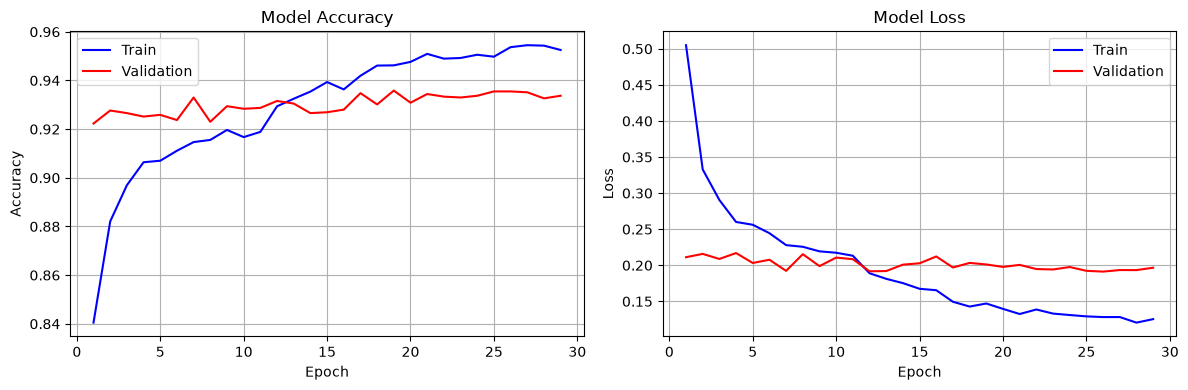

In [12]:
def plot_history(history):
    acc = history.history["accuracy"]
    val_acc = history.history["val_accuracy"]
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, "b-", label="Train")
    plt.plot(epochs, val_acc, "r-", label="Validation")
    plt.title("Model Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, "b-", label="Train")
    plt.plot(epochs, val_loss, "r-", label="Validation")
    plt.title("Model Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.savefig("training_history.png")
    plt.show()

plot_history(history)


## Fine-tuning

If the frozen-base model does not reach 95% test accuracy, unfreeze the top layers of EfficientNetB0 and train end-to-end with a very low learning rate.


In [13]:
# Evaluate before fine-tuning
print("Evaluating frozen-base model...")
train_loss, train_acc = model.evaluate(train_ds, verbose=0)
val_loss, val_acc = model.evaluate(val_ds, verbose=0)
test_loss, test_acc = model.evaluate(test_ds, verbose=0)

print(f"Train accuracy:      {train_acc:.4f}")
print(f"Validation accuracy: {val_acc:.4f}")
print(f"Test accuracy:       {test_acc:.4f}")

if train_acc >= 0.95 and test_acc >= 0.95:
    print("Target 95% accuracy already reached. Fine-tuning skipped.")
else:
    print("Unfreezing EfficientNetB0 top layers for fine-tuning...")
    base_model.trainable = True
    # Fine-tune only the top 30 layers to keep training stable.
    for layer in base_model.layers[:-40]:
        layer.trainable = False

    model.compile(
        optimizer=optimizers.Adam(learning_rate=1e-5),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )

    fine_tune_cb = [
        callbacks.EarlyStopping(monitor="val_accuracy", patience=5, restore_best_weights=True, verbose=1),
        callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-7, verbose=1),
    ]

    history_ft = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=15,
        callbacks=fine_tune_cb,
    )

    print("Re-evaluating after fine-tuning...")
    train_loss, train_acc = model.evaluate(train_ds, verbose=0)
    val_loss, val_acc = model.evaluate(val_ds, verbose=0)
    test_loss, test_acc = model.evaluate(test_ds, verbose=0)

    print(f"Train accuracy:      {train_acc:.4f}")
    print(f"Validation accuracy: {val_acc:.4f}")
    print(f"Test accuracy:       {test_acc:.4f}")

if train_acc < 0.95 or test_acc < 0.95:
    print("WARNING: accuracy below 95% bonus target (minimum 85% still required).")
else:
    print("Target 95% accuracy met.")


Evaluating frozen-base model...


Train accuracy:      0.9699
Validation accuracy: 0.9359
Test accuracy:       0.9243
Unfreezing EfficientNetB0 top layers for fine-tuning...


Epoch 1/15


  1/351 ━━━━━━━━━━━━━━━━━━━━ 1:02:41 11s/step - accuracy: 0.9375 - loss: 0.2486

  2/351 ━━━━━━━━━━━━━━━━━━━━ 2:06 362ms/step - accuracy: 0.8750 - loss: 0.3225 

...

351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 423ms/step - accuracy: 0.9409 - loss: 0.1578

351/351 ━━━━━━━━━━━━━━━━━━━━ 177s 503ms/step - accuracy: 0.9409 - loss: 0.1578 - val_accuracy: 0.9376 - val_loss: 0.1809 - learning_rate: 1.0000e-05


Restoring model weights from the end of the best epoch: 15.


Re-evaluating after fine-tuning...


Train accuracy:      0.9710
Validation accuracy: 0.9376
Test accuracy:       0.9333


## Export model in required formats

- SavedModel (TensorFlow standard)
- TF-Lite (mobile/embedded)
- TFJS (browser/JavaScript)


In [14]:
# SavedModel
shutil.rmtree("saved_model", ignore_errors=True)
model.export("saved_model")
print("SavedModel exported to ./saved_model")
print("SavedModel contents:", os.listdir("saved_model"))


INFO:tensorflow:Assets written to: saved_model/assets


INFO:tensorflow:Assets written to: saved_model/assets


Saved artifact at 'saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_243')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  124167605445712: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  124167605443984: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  124167624944592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  124167624944400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  124167624945168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  124167624945936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  124167624946512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  124167624944784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  124167624944976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  124167624946320: TensorSpec(shape=(), dtype=tf.resource, name=None)

SavedModel exported to ./saved_model
SavedModel contents: ['saved_model.pb', 'fingerprint.pb', 'assets', 'variables']


In [15]:
# TF-Lite
converter = tf.lite.TFLiteConverter.from_saved_model("saved_model")
tflite_model = converter.convert()

os.makedirs("tflite", exist_ok=True)
with open("tflite/model.tflite", "wb") as f:
    f.write(tflite_model)

with open("tflite/label.txt", "w") as f:
    f.write("\n".join(class_names))

print("TF-Lite model exported to ./tflite/model.tflite")
print("Labels:", class_names)


W0000 00:00:1787843003.931003   50063 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1787843003.933641   50063 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1787843004.085282   50063 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled


TF-Lite model exported to ./tflite/model.tflite
Labels: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


In [16]:
# TFJS
import tensorflowjs as tfjs

shutil.rmtree("tfjs_model", ignore_errors=True)
os.makedirs("tfjs_model", exist_ok=True)
tfjs.converters.save_keras_model(model, "tfjs_model")

print("TFJS model exported to ./tfjs_model")
print("TFJS contents:", os.listdir("tfjs_model"))


failed to lookup keras version from the file,
    this is likely a weight only file
weight normalization/count with shape () and dtype int64 was auto converted to the type int32


TFJS model exported to ./tfjs_model
TFJS contents: ['group1-shard4of5.bin', 'group1-shard1of5.bin', 'group1-shard3of5.bin', 'group1-shard5of5.bin', 'group1-shard2of5.bin', 'model.json']


## Inference proof

Load the SavedModel and run predictions on a batch from the test set.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


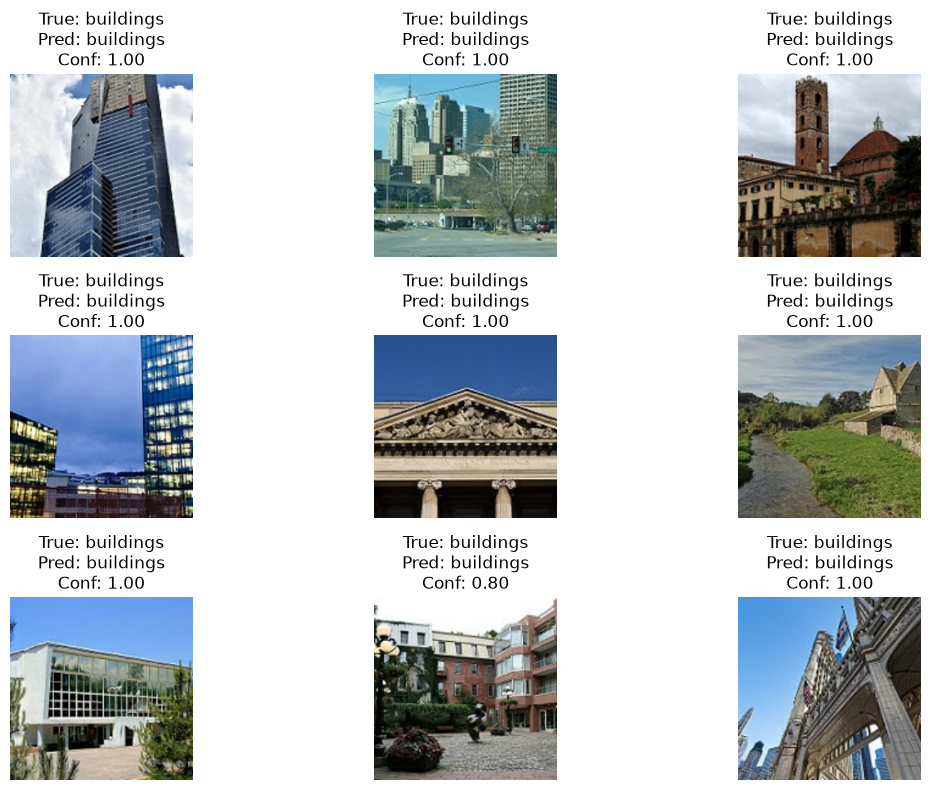

In [17]:
# Load SavedModel and predict
loaded_model = tf.keras.models.load_model("best_model.keras")

sample_images, sample_labels = next(iter(test_ds.take(1)))
preds = loaded_model.predict(sample_images)
pred_classes = np.argmax(preds, axis=1)
true_classes = np.argmax(sample_labels.numpy(), axis=1)

plt.figure(figsize=(12, 8))
for i in range(min(9, len(sample_images))):
    plt.subplot(3, 3, i + 1)
    plt.imshow(sample_images[i].numpy().astype("uint8"))
    plt.title(f"True: {class_names[true_classes[i]]}\nPred: {class_names[pred_classes[i]]}\nConf: {preds[i][pred_classes[i]]:.2f}")
    plt.axis("off")
plt.tight_layout()
plt.savefig("inference_samples.png")
plt.show()


In [18]:
# Verify submission artifacts exist
required = {
    "notebook.ipynb": os.path.exists("notebook.ipynb"),
    "saved_model/saved_model.pb": os.path.exists("saved_model/saved_model.pb"),
    "saved_model/variables": os.path.isdir("saved_model/variables"),
    "tflite/model.tflite": os.path.exists("tflite/model.tflite"),
    "tflite/label.txt": os.path.exists("tflite/label.txt"),
    "tfjs_model/model.json": os.path.exists("tfjs_model/model.json"),
}

for path, ok in required.items():
    print(f"{'[OK]' if ok else '[MISSING]'} {path}")

print("\nRecommended submission structure:")
print('''
submission/
├── tfjs_model/
│   ├── group1-shard1of1.bin
│   └── model.json
├── tflite/
│   ├── model.tflite
│   └── label.txt
├── saved_model/
│   ├── saved_model.pb
│   └── variables/
├── notebook.ipynb
├── README.md
└── requirements.txt
''')


[OK] notebook.ipynb
[OK] saved_model/saved_model.pb
[OK] saved_model/variables
[OK] tflite/model.tflite
[OK] tflite/label.txt
[OK] tfjs_model/model.json

Recommended submission structure:

submission/
├── tfjs_model/
│   ├── group1-shard1of1.bin
│   └── model.json
├── tflite/
│   ├── model.tflite
│   └── label.txt
├── saved_model/
│   ├── saved_model.pb
│   └── variables/
├── notebook.ipynb
├── README.md
└── requirements.txt

